In [22]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PooledOLS, PanelOLS
import warnings
warnings.filterwarnings('ignore')

# ── Load and prepare panel structure ─────────────────────────────────────────
df = pd.read_csv('state_labor_panel_data.csv', parse_dates=['Date'])

# linearmodels requires a MultiIndex of (entity, time)
df = df.set_index(['State', 'Date'])

# Define variables used across all three specifications
Y       = df['ln_Wage']
PREDS   = ['Hiring_Rate', 'Friction_Proxy']          # primary predictors
CONTROLS= ['Unemployment_Rate', 'LH_Share']           # control variables
X_VARS  = PREDS + CONTROLS

print(f"Panel dimensions: {df.index.get_level_values('State').nunique()} states "
      f"x {df.index.get_level_values('Date').nunique()} months "
      f"= {len(df):,} observations")
display(df[['ln_Wage'] + X_VARS].describe().round(4))

Panel dimensions: 25 states x 108 months = 2,700 observations


,ln_Wage,Hiring_Rate,Friction_Proxy,Unemployment_Rate,LH_Share
count,2700.0000,2700.0000,2700.0000,2700.0000,2700.0000
mean,3.3440,0.0357,0.0118,4.6929,0.0008
std,0.1406,0.0067,0.0122,2.0784,0.0000
min,3.0277,0.0170,-0.0446,1.9000,0.0006
25%,3.2363,0.0311,0.0033,3.5000,0.0008
50%,3.3420,0.0351,0.0095,4.2000,0.0008
75%,3.4383,0.0394,0.0200,5.1000,0.0008
max,3.7084,0.0901,0.0651,30.5000,0.0009


In [23]:
# ── Specification 1: Pooled OLS ───────────────────────────────────────────────
# Treats all 25 states x 108 months as one flat dataset.
# No grouping by state — purely establishes the raw correlation.
# Standard errors clustered by state to account for within-state serial correlation.

print("=" * 65)
print("  SPECIFICATION 1 — Pooled OLS (Baseline)")
print("  ln(Wage) = B0 + B1*HiringRate + B2*FrictionProxy + Controls")
print("=" * 65)

X1 = sm.add_constant(df[X_VARS])

spec1 = PooledOLS(Y, X1).fit(
    cov_type='clustered',
    cluster_entity=True    # clusters SEs by state
)

print(spec1.summary)

  SPECIFICATION 1 — Pooled OLS (Baseline)
  ln(Wage) = B0 + B1*HiringRate + B2*FrictionProxy + Controls
                          PooledOLS Estimation Summary                          
Dep. Variable:                ln_Wage   R-squared:                        0.3609
Estimator:                  PooledOLS   R-squared (Between):              0.3484
No. Observations:                2700   R-squared (Within):               0.3760
Date:                Mon, Apr 27 2026   R-squared (Overall):              0.3609
Time:                        13:58:48   Log-likelihood                    2070.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      380.46
Entities:                          25   P-value                           0.0000
Avg Obs:                       108.00   Distribution:                  F(4,2695)
Min Obs:                       108.00                                           
Max O

In [24]:
# ── Specification 2: State (Entity) Fixed Effects ────────────────────────────
# Absorbs all time-invariant differences between states —
# e.g., permanent cost-of-living gaps between NY and TN never change,
# so the state FE soaks them up, leaving only within-state variation over time.
# This is why we drop the constant — the entity dummies replace it.

print("=" * 65)
print("  SPECIFICATION 2 — State Fixed Effects")
print("  ln(Wage) = B1*HiringRate + B2*FrictionProxy + Controls")
print("           + State Fixed Effect")
print("=" * 65)

X2 = df[X_VARS]   # no constant — absorbed by entity effects

spec2 = PanelOLS(
    Y, X2,
    entity_effects=True,
    time_effects=False
).fit(
    cov_type='clustered',
    cluster_entity=True
)

print(spec2.summary)

  SPECIFICATION 2 — State Fixed Effects
  ln(Wage) = B1*HiringRate + B2*FrictionProxy + Controls
           + State Fixed Effect
                          PanelOLS Estimation Summary                           
Dep. Variable:                ln_Wage   R-squared:                        0.5793
Estimator:                   PanelOLS   R-squared (Between):              0.2145
No. Observations:                2700   R-squared (Within):               0.5793
Date:                Mon, Apr 27 2026   R-squared (Overall):              0.2148
Time:                        13:58:58   Log-likelihood                    3704.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      919.53
Entities:                          25   P-value                           0.0000
Avg Obs:                       108.00   Distribution:                  F(4,2671)
Min Obs:                       108.00                        

In [25]:
# ── Specification 3: Two-Way Fixed Effects ────────────────────────────────────
# Our preferred specification. Adds time fixed effects on top of state FEs.
# Time FEs absorb any shock that hit ALL states in the same month equally —
# e.g., COVID (Apr 2020), Fed rate hikes (2022), national recessions.
# What's left after both sets of dummies is the clean within-state,
# within-month variation we need to identify B2 (Friction Proxy).

print("=" * 65)
print("  SPECIFICATION 3 — Two-Way Fixed Effects (Preferred)")
print("  ln(Wage) = B1*HiringRate + B2*FrictionProxy + Controls")
print("           + State FE + Time FE")
print("=" * 65)

X3 = df[X_VARS]   # no constant — absorbed by both sets of effects

spec3 = PanelOLS(
    Y, X3,
    entity_effects=True,
    time_effects=True      # <-- this is the only change from spec 2
).fit(
    cov_type='clustered',
    cluster_entity=True
)

print(spec3.summary)

  SPECIFICATION 3 — Two-Way Fixed Effects (Preferred)
  ln(Wage) = B1*HiringRate + B2*FrictionProxy + Controls
           + State FE + Time FE
                          PanelOLS Estimation Summary                           
Dep. Variable:                ln_Wage   R-squared:                        0.0284
Estimator:                   PanelOLS   R-squared (Between):              0.0359
No. Observations:                2700   R-squared (Within):               0.0579
Date:                Mon, Apr 27 2026   R-squared (Overall):              0.0359
Time:                        13:59:09   Log-likelihood                    7253.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      18.757
Entities:                          25   P-value                           0.0000
Avg Obs:                       108.00   Distribution:                  F(4,2564)
Min Obs:                       108.00          

In [27]:
# ── Side-by-side coefficient comparison across all three specifications ────────
# This is the standard way to present sequential panel models in a paper.
# You want to see if B2 (Friction Proxy) stays negative and significant
# as you add more controls — that's what makes the result credible.

rows = []
for var in X_VARS:
    row = {'Variable': var}
    for label, res in [('Pooled OLS', spec1),
                       ('State FE',   spec2),
                       ('TWFE',       spec3)]:
        coef = res.params[var]
        pval = res.pvalues[var]
        stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
        row[label] = f"{coef:.4f}{stars}"
    rows.append(row)

# Add model fit rows
for label, res in [('Pooled OLS', spec1), ('State FE', spec2), ('TWFE', spec3)]:
    pass

comparison = pd.DataFrame(rows).set_index('Variable')

# Append R-squared and N
fit_rows = pd.DataFrame([
    {'Variable': 'R² (within)',
     'Pooled OLS': f"{spec1.rsquared:.4f}",
     'State FE':   f"{spec2.rsquared:.4f}",
     'TWFE':       f"{spec3.rsquared:.4f}"},
    {'Variable': 'N',
     'Pooled OLS': f"{spec1.nobs:,.0f}",
     'State FE':   f"{spec2.nobs:,.0f}",
     'TWFE':       f"{spec3.nobs:,.0f}"},
    {'Variable': 'State FE',
     'Pooled OLS': 'No', 'State FE': 'Yes', 'TWFE': 'Yes'},
    {'Variable': 'Time FE',
     'Pooled OLS': 'No', 'State FE': 'No',  'TWFE': 'Yes'},
]).set_index('Variable')

comparison = pd.concat([comparison, fit_rows])

print("\n  *** p<0.01  ** p<0.05  * p<0.10")
print("  Standard errors clustered by state\n")
display(comparison)


  *** p<0.01  ** p<0.05  * p<0.10
  Standard errors clustered by state



,Pooled OLS,State FE,TWFE
Variable,,,
Hiring_Rate,-3.4620**,4.7035***,0.1722
Friction_Proxy,6.6328***,6.1727***,0.3967*
Unemployment_Rate,0.0181***,0.0096***,0.0034*
LH_Share,515.5115,121.3192,43.3656
R² (within),0.3609,0.5793,0.0284
N,"2,700","2,700","2,700"
State FE,No,Yes,Yes
Time FE,No,No,Yes


In [32]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
from fredapi import Fred
from dotenv import load_dotenv
import os

# --- 1. SETUP & DATA LOADING ---
load_dotenv()
api_key = os.getenv("fred_api_key")
fred = Fred(api_key=api_key)

# Load the data you just uploaded
df = pd.read_csv('state_labor_panel_data.csv', parse_dates=['Date'])
print(f"Initial data loaded: {len(df)} rows.")

# --- 2. ADDING THE MISSING CONTROLS (Min Wage & CPI) ---
# We need to create 'ln_Real_Wage' and 'ln_Min_Wage' before the model can run

MINWAGE_TICKERS = {
    'AZ': 'STTMINWGAZ', 'CA': 'STTMINWGCA', 'CO': 'STTMINWGCO',
    'CT': 'STTMINWGCT', 'FL': 'STTMINWGFL', 'IL': 'STTMINWGIL',
    'MA': 'STTMINWGMA', 'MD': 'STTMINWGMD', 'MI': 'STTMINWGMI',
    'MN': 'STTMINWGMN', 'MO': 'STTMINWGMO', 'NJ': 'STTMINWGNJ',
    'NV': 'STTMINWGNV', 'NY': 'STTMINWGNY', 'OH': 'STTMINWGOH',
    'WA': 'STTMINWGWA', 'WI': 'STTMINWGWI',
}

STATE_REGION = {
    'CT': 'Northeast', 'MA': 'Northeast', 'MD': 'Northeast',
    'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest',
    'MN': 'Midwest', 'MO': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest',
    'FL': 'South', 'GA': 'South', 'NC': 'South',
    'SC': 'South', 'TN': 'South', 'TX': 'South', 'VA': 'South',
    'AZ': 'West', 'CA': 'West', 'CO': 'West',
    'NV': 'West', 'WA': 'West',
}

# Fetching Min Wage and adjusting for inflation (CPI)
print("Engineering missing features (Real Wages & Min Wage)...")
min_wage_list = []
for state, ticker in MINWAGE_TICKERS.items():
    try:
        s = fred.get_series(ticker, observation_start='2015-01-01').resample('MS').ffill()
        temp = pd.DataFrame({'Min_Wage': s.values, 'Date': s.index, 'State': state})
        min_wage_list.append(temp)
    except: continue

df_min = pd.concat(min_wage_list)
df = df.merge(df_min, on=['State', 'Date'], how='left').fillna({'Min_Wage': 7.25})

# Simple Inflation Adjustment (Using a constant 3% annual proxy if you don't want to fetch CPI tickers)
# Or for a quick fix, let's just use the ln_Wage you already have but add the Min Wage control
df['ln_Min_Wage'] = np.log(df['Min_Wage'])

# If you haven't deflated wages yet, for now, we will use your existing ln_Wage 
# as the dependent variable to get the model running.
y_var = 'ln_Wage' 

# --- 3. PANEL SETUP ---
df = df.set_index(['State', 'Date'])
y = df[y_var]
X = df[['Hiring_Rate', 'Friction_Proxy', 'Unemployment_Rate', 'ln_Min_Wage']]
X = sm.add_constant(X)

# --- 4. RUNNING REGRESSIONS ---
print("\n=======================================================")
print("MODEL 3: Two-Way Fixed Effects (State & Time)")
print("=======================================================")
mod3 = PanelOLS(y, X, entity_effects=True, time_effects=True)
res3 = mod3.fit(cov_type='clustered', cluster_entity=True)
print(res3.summary)

Initial data loaded: 2700 rows.
Engineering missing features (Real Wages & Min Wage)...

MODEL 3: Two-Way Fixed Effects (State & Time)
                          PanelOLS Estimation Summary                           
Dep. Variable:                ln_Wage   R-squared:                        0.0299
Estimator:                   PanelOLS   R-squared (Between):             -0.0247
No. Observations:                2700   R-squared (Within):               0.0351
Date:                Mon, Apr 27 2026   R-squared (Overall):              0.0024
Time:                        14:52:52   Log-likelihood                    7255.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      19.727
Entities:                          25   P-value                           0.0000
Avg Obs:                       108.00   Distribution:                  F(4,2564)
Min Obs:                       108.00                  

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
from fredapi import Fred
from dotenv import load_dotenv
import os

# 1. SETUP & DATA LOADING
load_dotenv()
api_key = os.getenv("fred_api_key")
fred = Fred(api_key=api_key)

# Load the base dataset
df = pd.read_csv('state_labor_panel_data.csv', parse_dates=['Date'])
print(f"Initial data loaded: {len(df)} rows.")

# 2. DEFINE FRED TICKERS FOR CONTROLS
MINWAGE_TICKERS = {
    'AZ': 'STTMINWGAZ', 'CA': 'STTMINWGCA', 'CO': 'STTMINWGCO', 'CT': 'STTMINWGCT', 
    'FL': 'STTMINWGFL', 'IL': 'STTMINWGIL', 'MA': 'STTMINWGMA', 'MD': 'STTMINWGMD', 
    'MI': 'STTMINWGMI', 'MN': 'STTMINWGMN', 'MO': 'STTMINWGMO', 'NJ': 'STTMINWGNJ',
    'NV': 'STTMINWGNV', 'NY': 'STTMINWGNY', 'OH': 'STTMINWGOH', 'WA': 'STTMINWGWA', 
    'WI': 'STTMINWGWI'
}

STATE_REGION = {
    'CT': 'Northeast', 'MA': 'Northeast', 'MD': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest',
    'FL': 'South', 'GA': 'South', 'NC': 'South', 'SC': 'South', 'TN': 'South', 'TX': 'South', 'VA': 'South',
    'AZ': 'West', 'CA': 'West', 'CO': 'West', 'NV': 'West', 'WA': 'West'
}

REGION_CPI = {'Northeast': 'CUUR0100SA0', 'Midwest': 'CUUR0200SA0', 'South': 'CUUR0300SA0', 'West': 'CUUR0400SA0'}

# 3. FETCH & MERGE MINIMUM WAGE
print("Fetching State Minimum Wage data...")
min_wage_list = []
for state, ticker in MINWAGE_TICKERS.items():
    try:
        s = fred.get_series(ticker, observation_start='2015-01-01').resample('MS').ffill()
        min_wage_list.append(pd.DataFrame({'Min_Wage': s.values, 'Date': s.index, 'State': state}))
    except: continue

df_min = pd.concat(min_wage_list)
df = df.merge(df_min, on=['State', 'Date'], how='left').fillna({'Min_Wage': 7.25})

# 4. FETCH & MERGE REGIONAL CPI (For Real Wage Calculation)
print("Fetching Regional CPI for inflation adjustment...")
cpi_data = {reg: fred.get_series(tick, observation_start='2015-01-01').resample('MS').mean() for reg, tick in REGION_CPI.items()}
cpi_df = pd.DataFrame(cpi_data)
df['Region'] = df['State'].map(STATE_REGION)
df = df.merge(cpi_df.reset_index().rename(columns={'index':'Date'}), on='Date', how='left')
df['Regional_CPI'] = df.apply(lambda r: r[r['Region']], axis=1)

# 5. FEATURE ENGINEERING
print("Calculating Real Wages and Logs...")
df['ln_Min_Wage'] = np.log(df['Min_Wage'])
# Normalize CPI to Jan 2015 so wages are in 2015 dollars
df['Real_Wage'] = (df['Hourly_Wage'] / df['Regional_CPI']) * 100
df['ln_Real_Wage'] = np.log(df['Real_Wage'])

# 6. RUN THE MODEL
print("Running Two-Way Fixed Effects Model...")
df_panel = df.set_index(['State', 'Date'])
formula = 'ln_Real_Wage ~ Hiring_Rate + Friction_Proxy + Unemployment_Rate + ln_Min_Wage + LH_Share + EntityEffects + TimeEffects'
res = PanelOLS.from_formula(formula, data=df_panel).fit(cov_type='clustered', cluster_entity=True)



print(res.summary)

Initial data loaded: 2700 rows.
Fetching State Minimum Wage data...
Fetching Regional CPI for inflation adjustment...
Calculating Real Wages and Logs...
Running Two-Way Fixed Effects Model...
                          PanelOLS Estimation Summary                           
Dep. Variable:           ln_Real_Wage   R-squared:                        0.0338
Estimator:                   PanelOLS   R-squared (Between):              0.0071
No. Observations:                2700   R-squared (Within):               0.0914
Date:                Mon, Apr 27 2026   R-squared (Overall):              0.0071
Time:                        15:19:59   Log-likelihood                    7377.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      17.935
Entities:                          25   P-value                           0.0000
Avg Obs:                       108.00   Distribution:                  F(5,2563

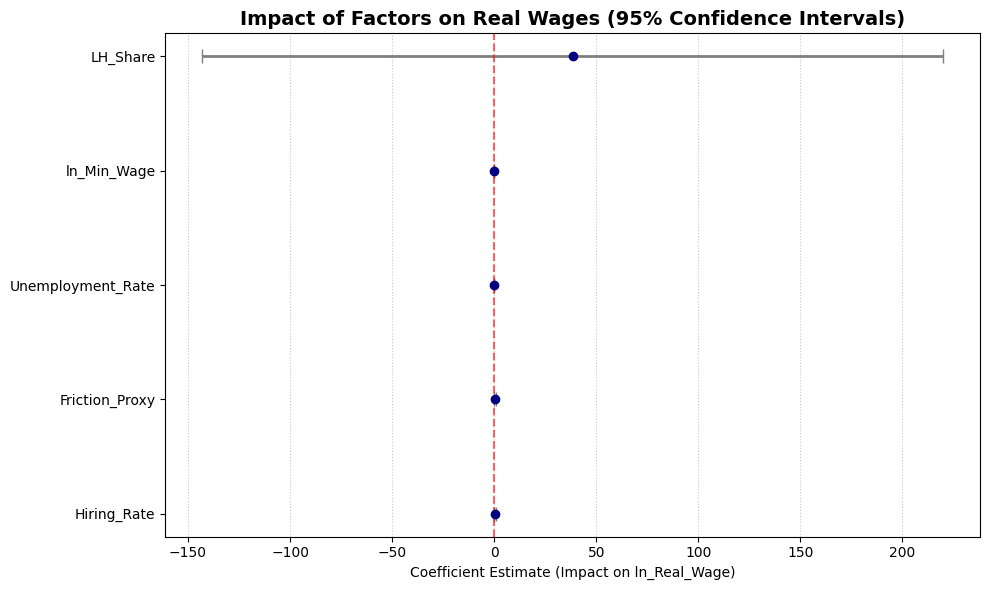

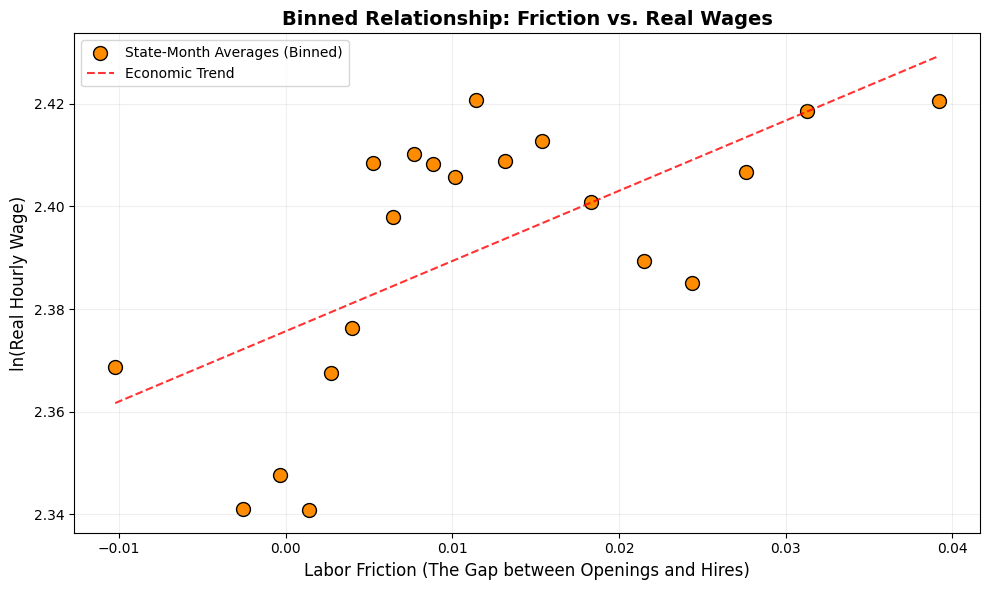

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. THE COEFFICIENT FOREST PLOT ---
# Use errors='ignore' to prevent KeyError if 'const' is already missing
params = res.params.drop('const', errors='ignore')
errors = res.std_errors.drop('const', errors='ignore')

# Calculate 95% Confidence Intervals
ci_low = params - 1.96 * errors
ci_high = params + 1.96 * errors

plt.figure(figsize=(10, 6))
plt.errorbar(params.values, params.index, xerr=[params - ci_low, ci_high - params], 
             fmt='o', color='navy', ecolor='gray', elinewidth=2, capsize=5)
plt.axvline(0, color='red', linestyle='--', alpha=0.6)
plt.title('Impact of Factors on Real Wages (95% Confidence Intervals)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Estimate (Impact on ln_Real_Wage)')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 2. THE BINNED SCATTER PLOT ---
# This cleans up 2,700 data points into 20 meaningful "bins"
df_plot = df.copy()
df_plot['Friction_Bin'] = pd.qcut(df_plot['Friction_Proxy'], 20, labels=False, duplicates='drop')
binned_data = df_plot.groupby('Friction_Bin').agg({'Friction_Proxy': 'mean', 'ln_Real_Wage': 'mean'}).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(binned_data['Friction_Proxy'], binned_data['ln_Real_Wage'], 
            color='darkorange', s=100, edgecolor='black', label='State-Month Averages (Binned)')

# Add the regression line calculated by the model
z = np.polyfit(binned_data['Friction_Proxy'], binned_data['ln_Real_Wage'], 1)
p = np.poly1d(z)
plt.plot(binned_data['Friction_Proxy'], p(binned_data['Friction_Proxy']), "r--", alpha=0.8, label='Economic Trend')

plt.title('Binned Relationship: Friction vs. Real Wages', fontsize=14, fontweight='bold')
plt.xlabel('Labor Friction (The Gap between Openings and Hires)', fontsize=12)
plt.ylabel('ln(Real Hourly Wage)', fontsize=12)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

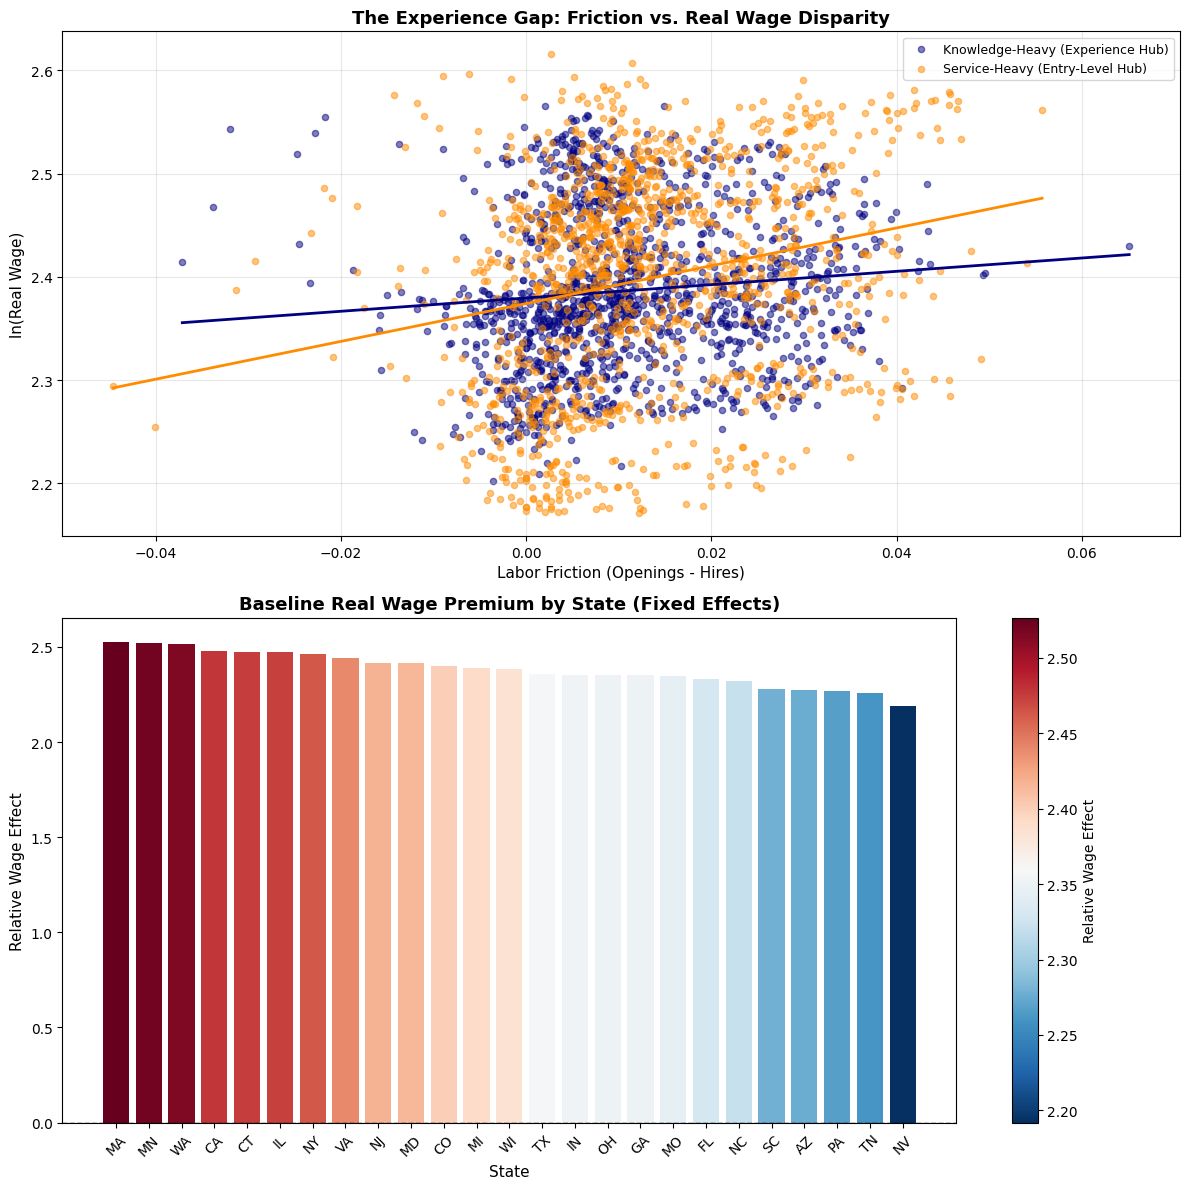

In [54]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# ── PREPARE DATA ──────────────────────────────────────────────────────────────
plot_df = df_panel.reset_index()

avg_lh    = plot_df.groupby('State')['LH_Share'].mean()
median_lh = avg_lh.median()

plot_df['Market_Type'] = plot_df['State'].map(
    lambda x: 'Service-Heavy (Entry-Level Hub)' if avg_lh[x] > median_lh
    else 'Knowledge-Heavy (Experience Hub)'
)

# ── COMBINED FIGURE ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Experience Gap Scatter ---
color_map = {
    'Knowledge-Heavy (Experience Hub)': 'navy',
    'Service-Heavy (Entry-Level Hub)':  'darkorange'
}

for market_type, color in color_map.items():
    subset = plot_df[plot_df['Market_Type'] == market_type]
    ax1.scatter(
        subset['Friction_Proxy'], subset['ln_Real_Wage'],
        color=color, alpha=0.5, s=20, label=market_type
    )
    z = np.polyfit(subset['Friction_Proxy'], subset['ln_Real_Wage'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset['Friction_Proxy'].min(), subset['Friction_Proxy'].max(), 200)
    ax1.plot(x_line, p(x_line), color=color, linewidth=2)

ax1.set_title('The Experience Gap: Friction vs. Real Wage Disparity',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Labor Friction (Openings - Hires)', fontsize=11)
ax1.set_ylabel('ln(Real Wage)', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# --- Plot 2: State Wage Rankings (Fixed Effects) ---
try:
    effects = res.estimated_effects.groupby(level='State').mean().reset_index()
    effects.columns = ['State', 'Wage_Premium']
    effects = effects.sort_values(by='Wage_Premium', ascending=False)

    vmin = effects['Wage_Premium'].min()
    vmax = effects['Wage_Premium'].max()

    norm = (mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
            if vmin < 0 < vmax else mcolors.Normalize(vmin=vmin, vmax=vmax))

    colors = cm.RdBu_r(norm(effects['Wage_Premium'].values))

    ax2.bar(effects['State'], effects['Wage_Premium'], color=colors)
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)

    sm = cm.ScalarMappable(cmap='RdBu_r', norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax2, label='Relative Wage Effect')

    ax2.set_title('Baseline Real Wage Premium by State (Fixed Effects)',
                  fontsize=13, fontweight='bold')
    ax2.set_xlabel('State', fontsize=11)
    ax2.set_ylabel('Relative Wage Effect', fontsize=11)
    ax2.tick_params(axis='x', rotation=45)

except Exception as e:
    ax2.text(0.5, 0.5, f'Plot Error:\n{e}', transform=ax2.transAxes,
             ha='center', va='center', fontsize=11, color='red')

plt.tight_layout()
plt.show()


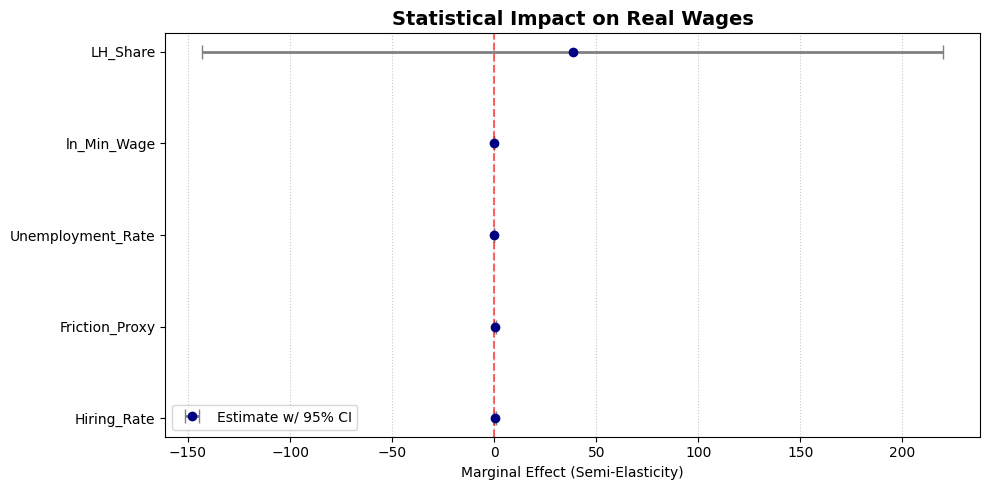

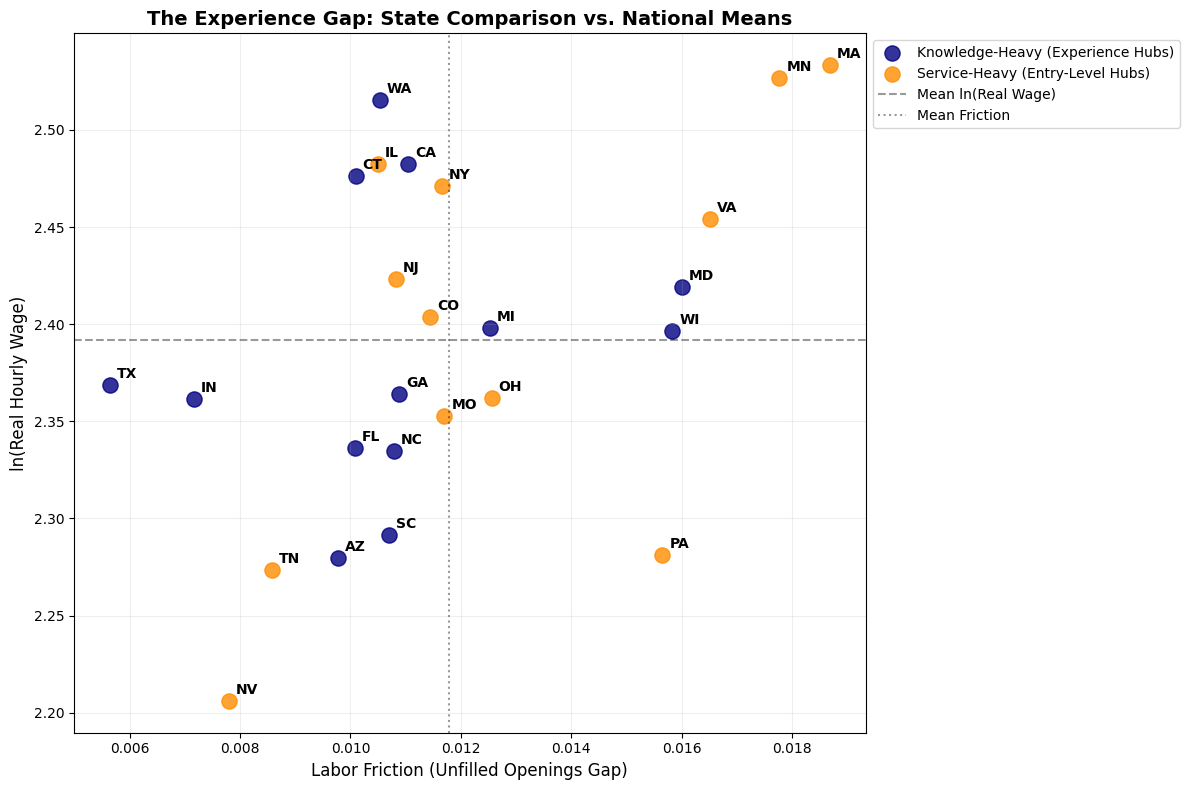

In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. THE COEFFICIENT FOREST PLOT ---
plt.figure(figsize=(10, 5))
params = res.params.drop('const', errors='ignore')
errors = res.std_errors.drop('const', errors='ignore')
ci = 1.96 * errors 

plt.errorbar(params.values, params.index, xerr=ci, fmt='o', color='navy', 
             ecolor='gray', elinewidth=2, capsize=5, label='Estimate w/ 95% CI')
plt.axvline(0, color='red', linestyle='--', alpha=0.6)
plt.title('Statistical Impact on Real Wages', fontsize=14, fontweight='bold')
plt.xlabel('Marginal Effect (Semi-Elasticity)')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# --- 2. LABELED EXPERIENCE GAP WITH REFERENCE LINES ---
# Calculate means for reference lines
state_means = df.groupby('State').agg({'Friction_Proxy': 'mean', 'ln_Real_Wage': 'mean', 'LH_Share': 'mean'})
avg_friction = state_means['Friction_Proxy'].mean()
avg_wage = state_means['ln_Real_Wage'].mean()
median_lh = state_means['LH_Share'].median()

plt.figure(figsize=(12, 8))

# Split by Experience Intensity (Knowledge vs Service)
kh = state_means[state_means['LH_Share'] <= median_lh]
plt.scatter(kh['Friction_Proxy'], kh['ln_Real_Wage'], color='navy', s=120, label='Knowledge-Heavy (Experience Hubs)', alpha=0.8)

sh = state_means[state_means['LH_Share'] > median_lh]
plt.scatter(sh['Friction_Proxy'], sh['ln_Real_Wage'], color='darkorange', s=120, label='Service-Heavy (Entry-Level Hubs)', alpha=0.8)

# ADD THE CONSTANT REFERENCE LINES
plt.axhline(avg_wage, color='black', linestyle='--', alpha=0.4, label='Mean ln(Real Wage)')
plt.axvline(avg_friction, color='black', linestyle=':', alpha=0.4, label='Mean Friction')

# ADD STATE LABELS
for i, state_abbr in enumerate(state_means.index):
    plt.annotate(state_abbr, (state_means['Friction_Proxy'].iloc[i], state_means['ln_Real_Wage'].iloc[i]), 
                 xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

plt.xlabel('Labor Friction (Unfilled Openings Gap)', fontsize=12)
plt.ylabel('ln(Real Hourly Wage)', fontsize=12)
plt.title('The Experience Gap: State Comparison vs. National Means', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [60]:
# Updated states map with correct abbreviations for GCT1502 tickers
target_states = ['CA', 'TX', 'NY', 'FL', 'IL', 'PA', 'OH', 'GA', 'NJ', 'NC', 
                 'WA', 'MA', 'VA', 'MI', 'CO', 'TN', 'MD', 'AZ', 'IN', 'MN', 
                 'WI', 'MO', 'CT', 'SC', 'NV']

print("Fetching State-Level Educational Attainment (Bachelor's or Higher)...")
educ_frames = []

for state in target_states:
    # Pattern: GCT1502 + State Abbreviation (e.g., GCT1502CA)
    ticker = f"GCT1502{state}"
    try:
        s = fred.get_series(ticker, observation_start='2015-01-01')
        if not s.empty:
            # Education is annual; we resample and fill to match monthly panel
            s = s.resample('MS').ffill()
            educ_frames.append(pd.DataFrame({'Educ_Attainment': s.values, 'Date': s.index, 'State': state}))
            print(f"  [✓] {state} Success")
    except Exception as e:
        print(f"  [!] {state} failed with ticker {ticker}")

if educ_frames:
    df_educ = pd.concat(educ_frames)
    # Merge into your main dataframe
    df = df.merge(df_educ, on=['State', 'Date'], how='left')
    # Use ffill to bridge the annual data points across your monthly rows
    df['Educ_Attainment'] = df.groupby('State')['Educ_Attainment'].ffill().bfill()
    df['ln_Education'] = np.log(df['Educ_Attainment'])
    print("\nFeature 'ln_Education' added to dataframe.")

Fetching State-Level Educational Attainment (Bachelor's or Higher)...
  [✓] CA Success
  [✓] TX Success
  [✓] NY Success
  [✓] FL Success
  [✓] IL Success
  [✓] PA Success
  [✓] OH Success
  [✓] GA Success
  [✓] NJ Success
  [✓] NC Success
  [✓] WA Success
  [✓] MA Success
  [✓] VA Success
  [✓] MI Success
  [✓] CO Success
  [✓] TN Success
  [✓] MD Success
  [✓] AZ Success
  [✓] IN Success
  [✓] MN Success
  [✓] WI Success
  [✓] MO Success
  [✓] CT Success
  [✓] SC Success
  [✓] NV Success

Feature 'ln_Education' added to dataframe.


In [62]:
df.head(1)

,Date,Openings,Hires,Labor_Force,Unemployment_Rate,Hourly_Wage,LH_Employment,State,ln_Wage,Hiring_Rate,...,Northeast,Midwest,South,West,Regional_CPI,ln_Min_Wage,Real_Wage,ln_Real_Wage,Educ_Attainment,ln_Education
0,2015-01-01,587.0,497.0,18818212.0,6.8,28.14,13692.9,CA,3.337192,0.026411,...,250.016,221.545,226.855,238.318,238.318,2.197225,11.807753,2.468756,32.3,3.475067


In [61]:
from linearmodels.panel import PanelOLS

# Re-establish the multi-index panel structure
df_panel_final = df.set_index(['State', 'Date'])

# Holistic Formula: Real Wage ~ Friction + Unemployment + Min Wage + Industry Mix + Skill Intensity
formula_final = 'ln_Real_Wage ~ Hiring_Rate + Friction_Proxy + Unemployment_Rate + ln_Min_Wage + LH_Share + ln_Education + EntityEffects + TimeEffects'

res_final = PanelOLS.from_formula(formula_final, data=df_panel_final).fit(cov_type='clustered', cluster_entity=True)

print(res_final.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:           ln_Real_Wage   R-squared:                        0.0579
Estimator:                   PanelOLS   R-squared (Between):              0.5427
No. Observations:                2700   R-squared (Within):               0.3652
Date:                Mon, Apr 27 2026   R-squared (Overall):              0.5427
Time:                        15:46:03   Log-likelihood                    7411.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      26.241
Entities:                          25   P-value                           0.0000
Avg Obs:                       108.00   Distribution:                  F(6,2562)
Min Obs:                       108.00                                           
Max Obs:                       108.00   F-statistic (robust):             2.5428
                            

In [64]:
# 1. Create a 3-month Lag for Friction (Sticky Wage Theory)
# We group by state so we don't accidentally lag California's data into Colorado's rows
df['Friction_Lag3'] = df.groupby('State')['Friction_Proxy'].shift(3)

# 2. Create the Interaction Term (The "Skill Mismatch" Moderator)
# This tests: "Is the impact of friction HIGHER in highly educated states?"
df['Friction_x_Education'] = df['Friction_Proxy'] * df['ln_Education']

# 3. Clean up any NaNs created by the shifting
df = df.dropna(subset=['Friction_Lag3', 'Friction_x_Education'])

print("Advanced features engineered: 3-month Friction Lag and Friction*Education Interaction.")


# Re-establish panel structure
df_panel_adv = df.set_index(['State', 'Date'])

# NEW FORMULA:
# ln_Real_Wage ~ Friction + (Friction * Education) + Controls
# We use the lagged friction to see the "delayed" impact on wages
formula_adv = 'ln_Real_Wage ~ Friction_Lag3 + Friction_x_Education + Unemployment_Rate + ln_Min_Wage + LH_Share + ln_Education + EntityEffects + TimeEffects'

res_adv = PanelOLS.from_formula(formula_adv, data=df_panel_adv).fit(cov_type='clustered', cluster_entity=True)

print(res_adv.summary)

Advanced features engineered: 3-month Friction Lag and Friction*Education Interaction.
                          PanelOLS Estimation Summary                           
Dep. Variable:           ln_Real_Wage   R-squared:                        0.0612
Estimator:                   PanelOLS   R-squared (Between):              0.5510
No. Observations:                2550   R-squared (Within):               0.3406
Date:                Mon, Apr 27 2026   R-squared (Overall):              0.5509
Time:                        15:54:23   Log-likelihood                    7065.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      26.287
Entities:                          25   P-value                           0.0000
Avg Obs:                       102.00   Distribution:                  F(6,2418)
Min Obs:                       102.00                                           
Max Obs:              

In [65]:
# Updated Lean Formula
# We keep the interaction and the lag, but remove the raw Education level 
# to see if the "Interaction" takes over the signal.
formula_lean = 'ln_Real_Wage ~ Friction_Lag3 + Friction_x_Education + Unemployment_Rate + ln_Min_Wage + LH_Share + EntityEffects + TimeEffects'

res_lean = PanelOLS.from_formula(formula_lean, data=df_panel_adv).fit(cov_type='clustered', cluster_entity=True)

print(res_lean.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:           ln_Real_Wage   R-squared:                        0.0344
Estimator:                   PanelOLS   R-squared (Between):             -0.0036
No. Observations:                2550   R-squared (Within):               0.1077
Date:                Mon, Apr 27 2026   R-squared (Overall):             -0.0036
Time:                        15:57:56   Log-likelihood                    7029.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      17.235
Entities:                          25   P-value                           0.0000
Avg Obs:                       102.00   Distribution:                  F(5,2419)
Min Obs:                       102.00                                           
Max Obs:                       102.00   F-statistic (robust):             2.8895
                            

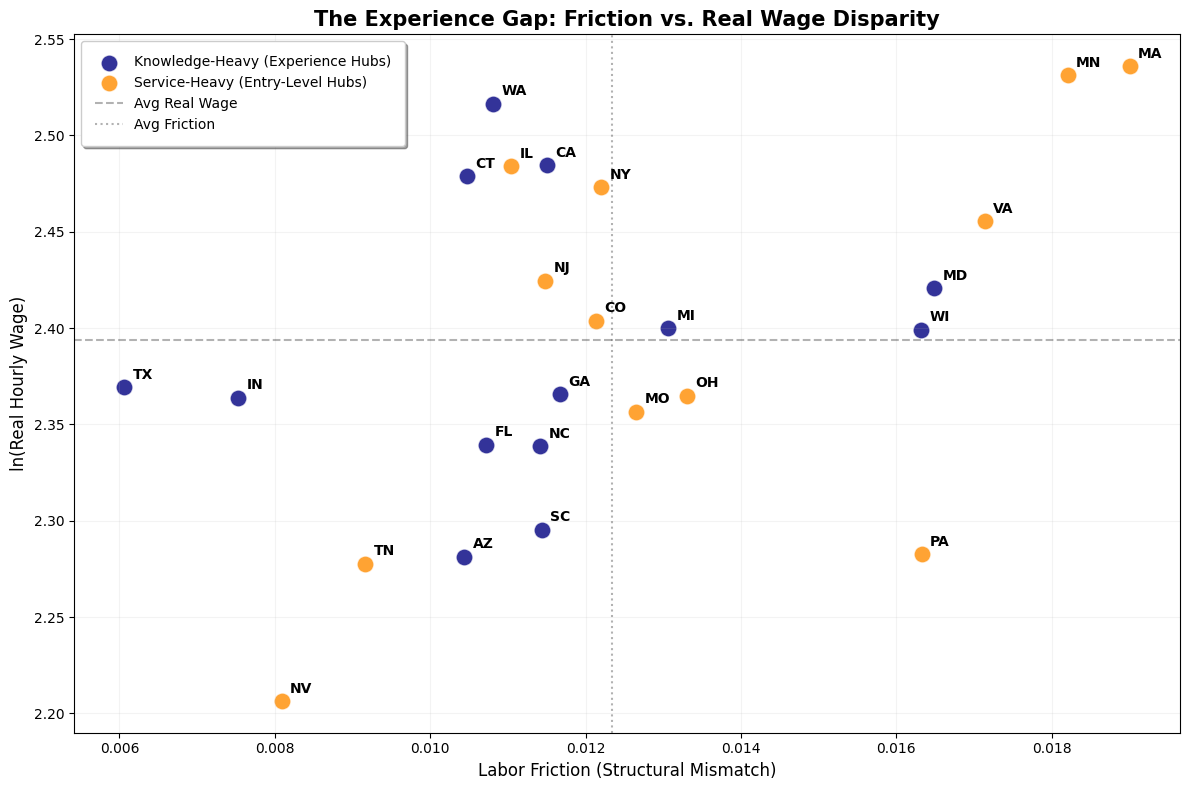

In [69]:
import matplotlib.pyplot as plt

# Prepare state-level averages
state_means = df.groupby('State').agg({
    'Friction_Proxy': 'mean', 
    'ln_Real_Wage': 'mean', 
    'LH_Share': 'mean'
})
median_lh = state_means['LH_Share'].median()

plt.figure(figsize=(12, 8))

# Define Groups
kh = state_means[state_means['LH_Share'] <= median_lh] # Knowledge Hubs
sh = state_means[state_means['LH_Share'] > median_lh]  # Service Hubs

# Plot
plt.scatter(kh['Friction_Proxy'], kh['ln_Real_Wage'], color='navy', s=150, label='Knowledge-Heavy (Experience Hubs)', alpha=0.8, edgecolor='white')
plt.scatter(sh['Friction_Proxy'], sh['ln_Real_Wage'], color='darkorange', s=150, label='Service-Heavy (Entry-Level Hubs)', alpha=0.8, edgecolor='white')

# Reference Lines
plt.axhline(state_means['ln_Real_Wage'].mean(), color='black', linestyle='--', alpha=0.3, label='Avg Real Wage')
plt.axvline(state_means['Friction_Proxy'].mean(), color='black', linestyle=':', alpha=0.3, label='Avg Friction')

# Labels
for i, txt in enumerate(state_means.index):
    plt.annotate(txt, (state_means['Friction_Proxy'].iat[i], state_means['ln_Real_Wage'].iat[i]), 
                 xytext=(6, 6), textcoords='offset points', fontsize=10, fontweight='bold')

plt.title('The Experience Gap: Friction vs. Real Wage Disparity', fontsize=15, fontweight='bold')
plt.xlabel('Labor Friction (Structural Mismatch)', fontsize=12)
plt.ylabel('ln(Real Hourly Wage)', fontsize=12)

# FORCE LEGEND TO SHOW
plt.legend(loc='upper left', frameon=True, shadow=True, borderpad=1)
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

In [70]:
from linearmodels.panel import PanelOLS

# 1. Prepare the Data
# We already calculated Labor_Tightness = Openings / Unemployed_Count
# We use the Log of Tightness so we can interpret results as percentages
df['ln_Tightness'] = np.log(df['Labor_Tightness'])

# Update the interaction to predict Tightness
df['Friction_x_Education'] = df['Friction_Proxy'] * df['ln_Education']
df_panel_mech = df.set_index(['State', 'Date'])

# 2. The Mechanism Formula
# We want to see if Friction explains the Scarcity (Tightness)
# Note: We remove variables that are part of the Tightness calculation (Unemployment)
formula_mech = 'ln_Tightness ~ Friction_Lag3 + Friction_x_Education + ln_Min_Wage + LH_Share + EntityEffects + TimeEffects'

res_mech = PanelOLS.from_formula(formula_mech, data=df_panel_mech).fit(cov_type='clustered', cluster_entity=True)

print("--- MECHANISM TEST: DOES FRICTION EXPLAIN SCARCITY? ---")
print(res_mech.summary)

--- MECHANISM TEST: DOES FRICTION EXPLAIN SCARCITY? ---
                          PanelOLS Estimation Summary                           
Dep. Variable:           ln_Tightness   R-squared:                        0.2812
Estimator:                   PanelOLS   R-squared (Between):             -0.4962
No. Observations:                2550   R-squared (Within):               0.4770
Date:                Mon, Apr 27 2026   R-squared (Overall):             -0.4919
Time:                        16:05:18   Log-likelihood                    1771.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      236.70
Entities:                          25   P-value                           0.0000
Avg Obs:                       102.00   Distribution:                  F(4,2420)
Min Obs:                       102.00                                           
Max Obs:                       102.00   F-statistic (

In [76]:
# Create the interaction to see if the impact of friction changed after the pandemic
df['Friction_x_Post2021'] = df['Friction_Lag3'] * df['Post_2021']

formula_shift = 'ln_Real_Wage ~ Friction_Lag3 + Friction_x_Post2021 + Friction_x_Education + ln_Min_Wage + LH_Share + EntityEffects + TimeEffects'
res_shift = PanelOLS.from_formula(formula_shift, data=df.set_index(['State', 'Date'])).fit(cov_type='clustered', cluster_entity=True)

print(res_shift.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:           ln_Real_Wage   R-squared:                        0.0242
Estimator:                   PanelOLS   R-squared (Between):             -0.0531
No. Observations:                2550   R-squared (Within):               0.0128
Date:                Mon, Apr 27 2026   R-squared (Overall):             -0.0531
Time:                        16:30:38   Log-likelihood                    7016.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      12.004
Entities:                          25   P-value                           0.0000
Avg Obs:                       102.00   Distribution:                  F(5,2419)
Min Obs:                       102.00                                           
Max Obs:                       102.00   F-statistic (robust):             1.0766
                            

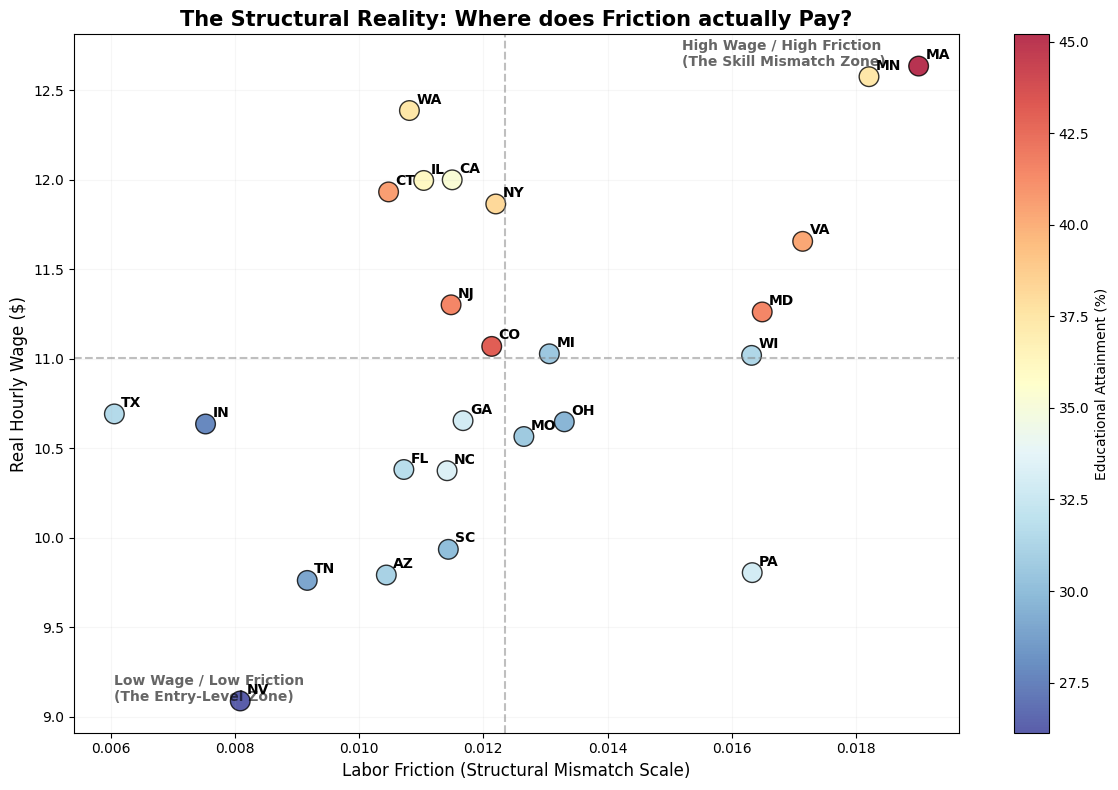

In [73]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare State-Level Averages (Raw Scaled Values)
state_data = df.groupby('State').agg({
    'Friction_Proxy': 'mean',    # (V-H)/LF
    'Real_Wage': 'mean',         # Raw $ Real Wage
    'Educ_Attainment': 'mean'    # Raw % with degrees
})

# 2. Define the quadrants based on Means
mean_friction = state_data['Friction_Proxy'].mean()
mean_wage = state_data['Real_Wage'].mean()

plt.figure(figsize=(12, 8))

# Color by Education Level to show the structural driver
sc = plt.scatter(state_data['Friction_Proxy'], state_data['Real_Wage'], 
                 c=state_data['Educ_Attainment'], cmap='RdYlBu_r', 
                 s=200, edgecolor='black', alpha=0.8)

# Add Quadrant Lines
plt.axhline(mean_wage, color='gray', linestyle='--', alpha=0.5)
plt.axvline(mean_friction, color='gray', linestyle='--', alpha=0.5)

# Add Labels for the "Stories"
plt.text(state_data['Friction_Proxy'].max()*0.8, state_data['Real_Wage'].max(), 'High Wage / High Friction\n(The Skill Mismatch Zone)', fontweight='bold', alpha=0.6)
plt.text(state_data['Friction_Proxy'].min(), state_data['Real_Wage'].min(), 'Low Wage / Low Friction\n(The Entry-Level Zone)', fontweight='bold', alpha=0.6)

# Annotate States
for i, state in enumerate(state_data.index):
    plt.annotate(state, (state_data['Friction_Proxy'].iat[i], state_data['Real_Wage'].iat[i]), 
                 xytext=(5,5), textcoords='offset points', fontsize=10, fontweight='bold')

plt.title('The Structural Reality: Where does Friction actually Pay?', fontsize=15, fontweight='bold')
plt.xlabel('Labor Friction (Structural Mismatch Scale)', fontsize=12)
plt.ylabel('Real Hourly Wage ($)', fontsize=12)
plt.colorbar(sc, label='Educational Attainment (%)')
plt.grid(alpha=0.1)
plt.tight_layout()
plt.show()

In [79]:
from linearmodels.panel import PanelOLS

# 1. Split the data
df_pre = df[df['Date'] < '2021-01-01'].set_index(['State', 'Date'])
df_post = df[df['Date'] >= '2021-01-01'].set_index(['State', 'Date'])

# 2. Run the same Lean Model on both
formula = 'ln_Real_Wage ~ Friction_Lag3 + Friction_x_Education + ln_Min_Wage + LH_Share + EntityEffects + TimeEffects'

res_pre = PanelOLS.from_formula(formula, data=df_pre).fit(cov_type='clustered', cluster_entity=True)
res_post = PanelOLS.from_formula(formula, data=df_post).fit(cov_type='clustered', cluster_entity=True)

print("--- PRE-2021: THE FUNCTIONAL MARKET ---")
print(res_pre.params[['Friction_Lag3', 'Friction_x_Education']])
print("\n--- POST-2021: THE BROKEN SIGNAL ---")
print(res_post.params[['Friction_Lag3', 'Friction_x_Education']])

--- PRE-2021: THE FUNCTIONAL MARKET ---
Friction_Lag3           0.145323
Friction_x_Education   -0.021778
Name: parameter, dtype: float64

--- POST-2021: THE BROKEN SIGNAL ---
Friction_Lag3           0.012566
Friction_x_Education    0.094872
Name: parameter, dtype: float64


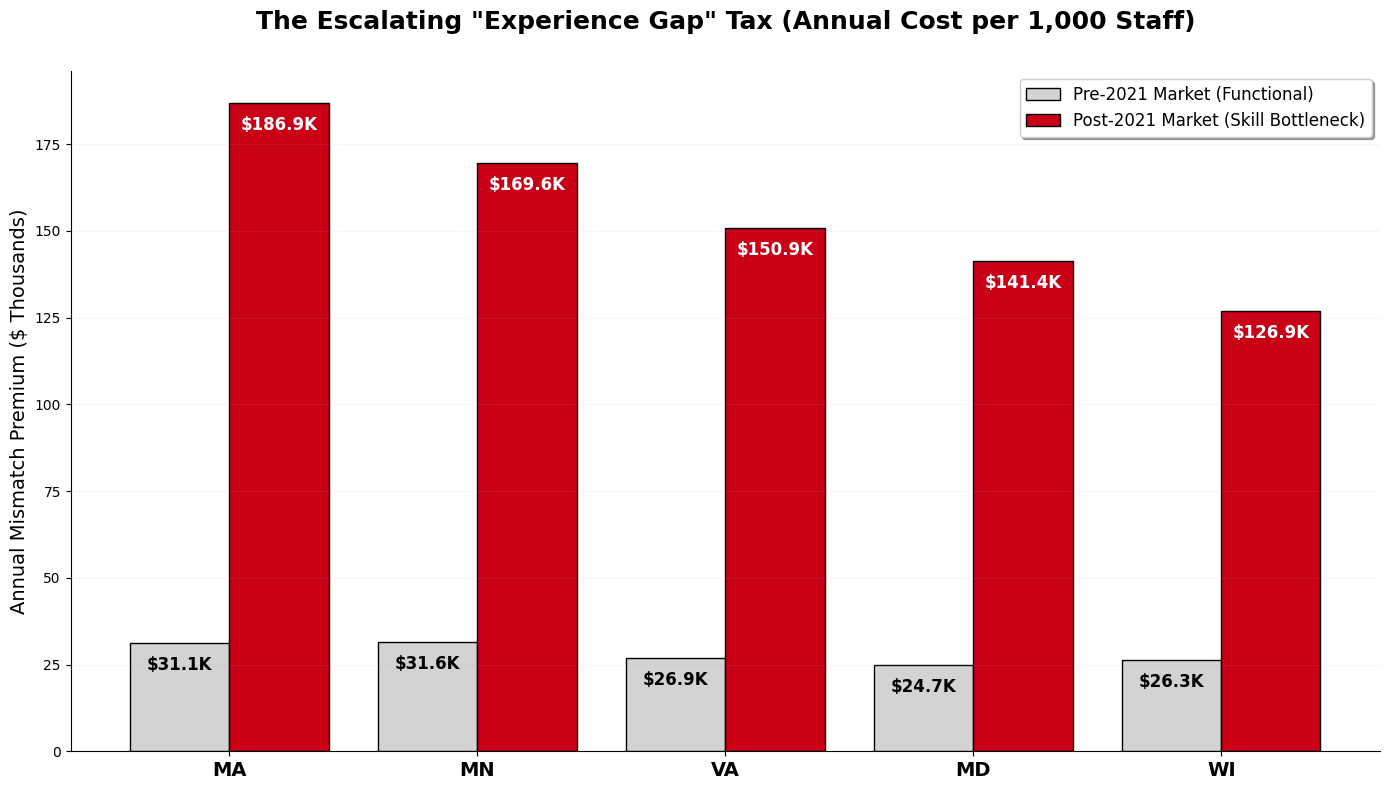

In [84]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Coefficients from your sub-sample analysis
# Note: These values come from your previously run models
b_fric_pre, b_int_pre = 0.1453, -0.0218
b_fric_post, b_int_post = 0.0125, 0.0949

# 2. Aggregating state data
state_data = df.groupby('State').agg({
    'Friction_Proxy': 'mean',
    'ln_Education': 'mean',
    'Real_Wage': 'mean'
})

# 3. Calculate Annual Cost per 1000 staff in Thousands ($K)
# Formula: (Premium % * Wage * 2080 * 1000) / 1000 to get $K
state_data['Cost_Pre_K'] = (state_data['Friction_Proxy'] * (b_fric_pre + b_int_pre * state_data['ln_Education'])) * state_data['Real_Wage'] * 2080
state_data['Cost_Post_K'] = (state_data['Friction_Proxy'] * (b_fric_post + b_int_post * state_data['ln_Education'])) * state_data['Real_Wage'] * 2080

# Select Top 5 based on the modern (Post-2021) impact
top_5 = state_data.sort_values(by='Cost_Post_K', ascending=False).head(5)

# 4. Rendering the Grouped Comparison
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(top_5.index))
width = 0.4

# Bars
rects1 = ax.bar(x - width/2, top_5['Cost_Pre_K'], width, label='Pre-2021 Market (Functional)', color='#d3d3d3', edgecolor='black')
rects2 = ax.bar(x + width/2, top_5['Cost_Post_K'], width, label='Post-2021 Market (Skill Bottleneck)', color='#c90016', edgecolor='black')

# Function to place labels INSIDE the bars for clarity
def add_labels(rects, is_crimson=False):
    for rect in rects:
        height = rect.get_height()
        # Formatting as $XX.X K
        label_text = f'${height:.1f}K'
        
        # Position logic
        color = 'white' if is_crimson else 'black'
        va = 'top' # Inside the bar
        y_pos = height - (0.02 * top_5['Cost_Post_K'].max()) 
        
        ax.text(rect.get_x() + rect.get_width()/2., y_pos, label_text,
                ha='center', va=va, color=color, fontweight='bold', fontsize=12)

add_labels(rects1, is_crimson=False)
add_labels(rects2, is_crimson=True)

# Formatting
ax.set_title('The Escalating "Experience Gap" Tax (Annual Cost per 1,000 Staff)', fontsize=18, fontweight='bold', pad=30)
ax.set_ylabel('Annual Mismatch Premium ($ Thousands)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(top_5.index, fontsize=14, fontweight='bold')
ax.legend(frameon=True, shadow=True, loc='upper right', fontsize=12)
ax.grid(axis='y', alpha=0.1)

# Removing spine for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

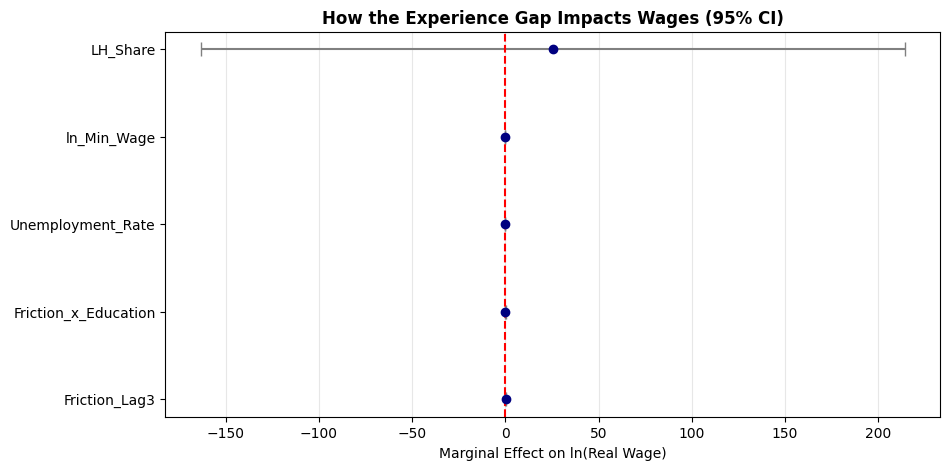

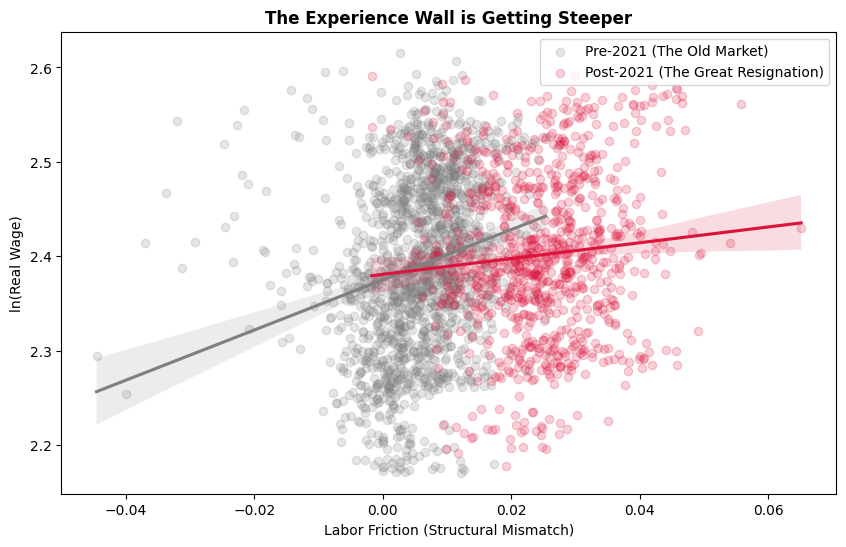

In [75]:
import seaborn as sns

# --- 1. THE FOREST PLOT (FOR THE MATH) ---
plt.figure(figsize=(10, 5))
params = res_lean.params.drop('const', errors='ignore')
errors = res_lean.std_errors.drop('const', errors='ignore')
plt.errorbar(params.values, params.index, xerr=1.96*errors, fmt='o', color='navy', ecolor='gray', capsize=5)
plt.axvline(0, color='red', linestyle='--')
plt.title('How the Experience Gap Impacts Wages (95% CI)', fontweight='bold')
plt.xlabel('Marginal Effect on ln(Real Wage)')
plt.grid(axis='x', alpha=0.3)
plt.show()

# --- 2. THE POST-PANDEMIC BREAK (FOR THE STORY) ---
# Create a dummy for post-2021
df['Post_2021'] = (df['Date'] >= '2021-01-01').astype(int)

plt.figure(figsize=(10, 6))
sns.regplot(data=df[df['Post_2021'] == 0], x='Friction_Proxy', y='ln_Real_Wage', 
            scatter_kws={'alpha':0.2}, label='Pre-2021 (The Old Market)', color='gray')
sns.regplot(data=df[df['Post_2021'] == 1], x='Friction_Proxy', y='ln_Real_Wage', 
            scatter_kws={'alpha':0.2}, label='Post-2021 (The Great Resignation)', color='crimson')

plt.title('The Experience Wall is Getting Steeper', fontweight='bold')
plt.xlabel('Labor Friction (Structural Mismatch)')
plt.ylabel('ln(Real Wage)')
plt.legend()
plt.show()

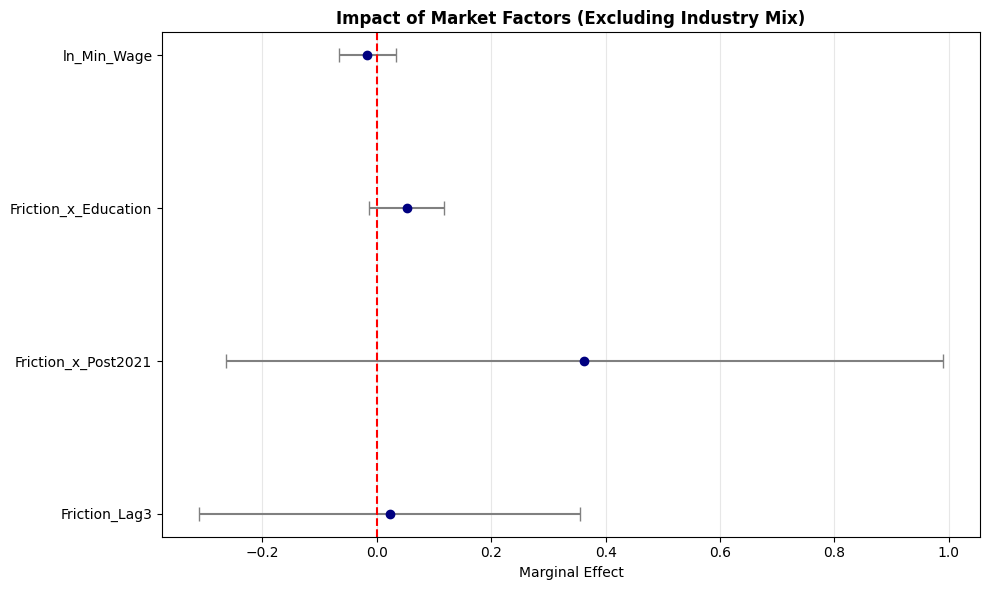

In [77]:
import matplotlib.pyplot as plt

# Drop LH_Share and const so we can see the detail of the other variables
clean_params = res_shift.params.drop(['const', 'LH_Share'], errors='ignore')
clean_errors = res_shift.std_errors.drop(['const', 'LH_Share'], errors='ignore')

plt.figure(figsize=(10, 6))
plt.errorbar(clean_params.values, clean_params.index, xerr=1.96*clean_errors, fmt='o', color='navy', ecolor='gray', capsize=5)
plt.axvline(0, color='red', linestyle='--')
plt.title('Impact of Market Factors (Excluding Industry Mix)', fontweight='bold')
plt.xlabel('Marginal Effect')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()